<a href="https://colab.research.google.com/github/JBar3118/CSE-498-Healthcare-and-Robotics/blob/main/Pretrained_YOLOV11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/valeriouberti/webcam-object-recognition.git

Cloning into 'webcam-object-recognition'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 11 (delta 2), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 5.36 MiB | 45.73 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
%cd webcam-object-recognition

/content/webcam-object-recognition


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("Ultralytics imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics imported successfully!


In [ ]:
model = YOLO("yolo11n.pt")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving En.png to En.png
Saving expes1.png to expes1.png
Saving expes3.jpg to expes3.jpg
Saving expes4.jpg to expes4.jpg
Saving ITposter.jpg to ITposter.jpg


In [ ]:
results = model.predict(
    source="expes3.jpg",
    save=True,
    conf=0.25
)


image 1/1 /content/webcam-object-recognition/expes3.jpg: 640x544 (no detections), 8.1ms
Speed: 107.3ms preprocess, 8.1ms inference, 6.2ms postprocess per image at shape (1, 3, 640, 544)
Results saved to /content/webcam-object-recognition/runs/detect/predict


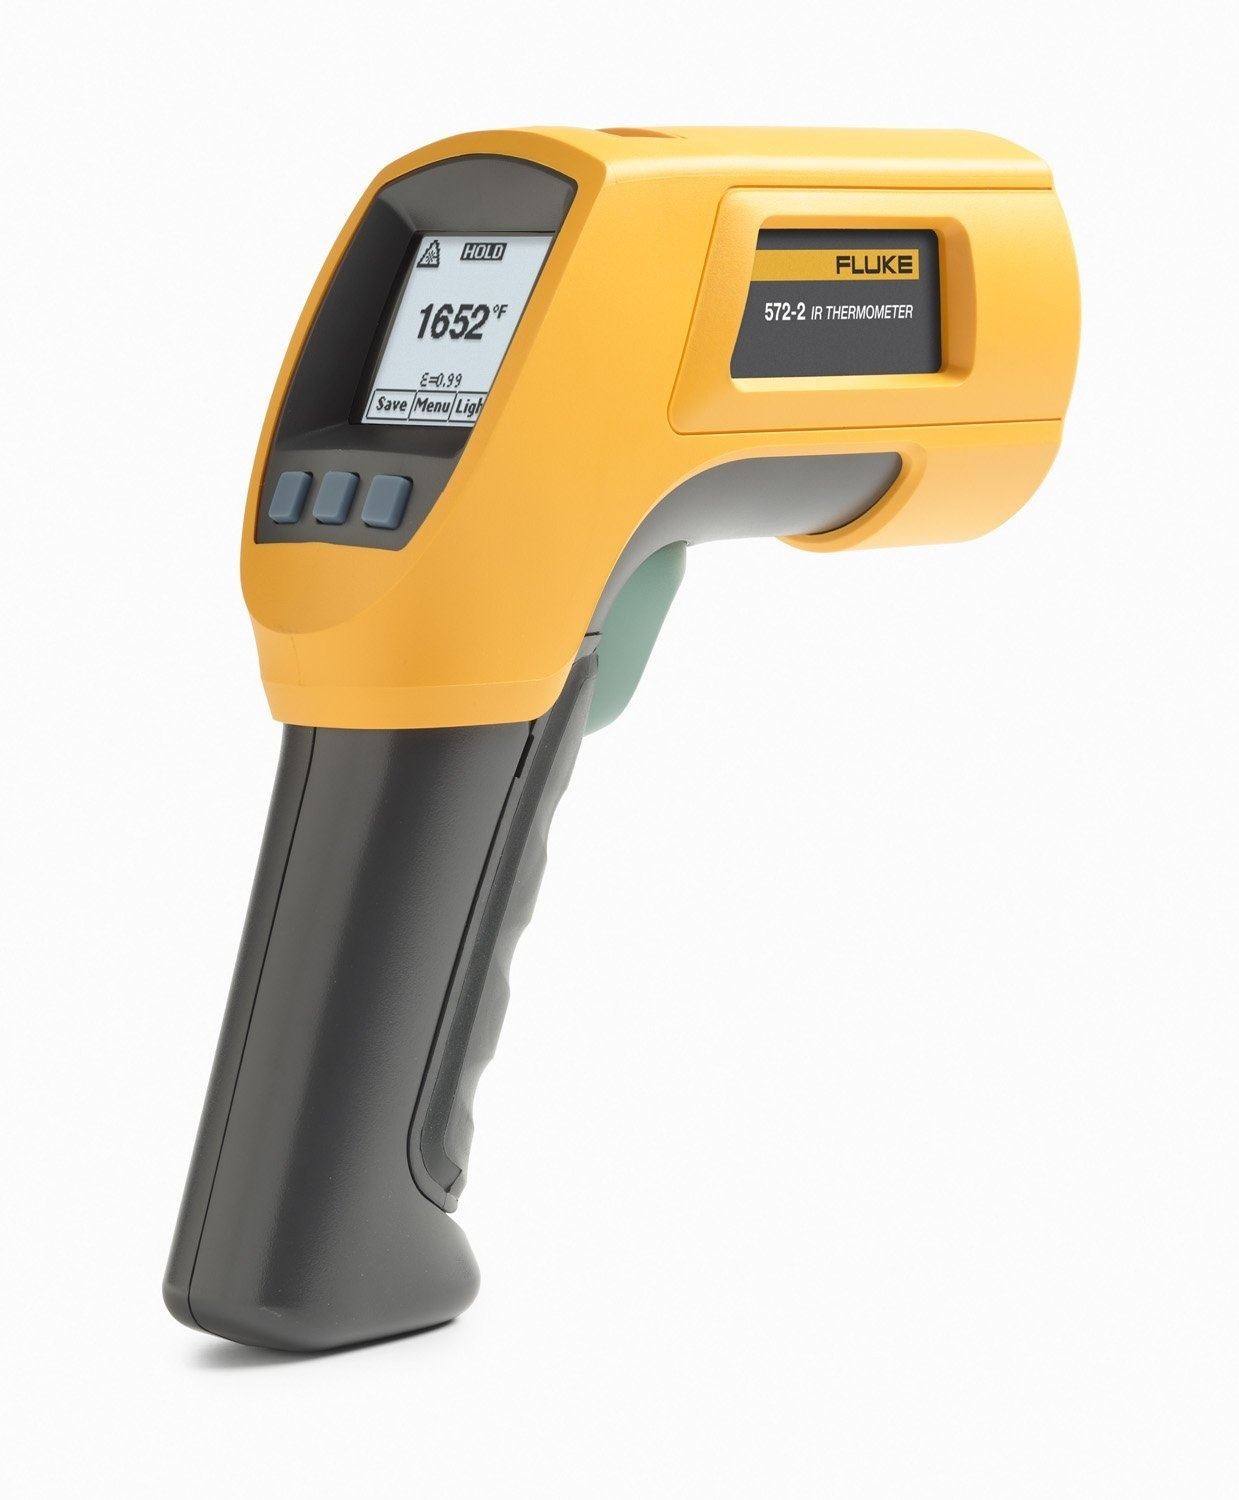

In [ ]:
from IPython.display import Image, display

display(Image(filename="runs/detect/predict/expes3.jpg"))

In [ ]:
!ls runs/detect/

predict


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="xxyX1zF7WZWkMTiEPdLV")
project = rf.workspace("brad-dwyer").project("hard-hat-sample")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Sample-1 in yolov11:: 100%|██████████| 212/212 [00:00<00:00, 6799.93it/s]


In [ ]:
!find . -name "data.yaml"

./Hard-Hat-Sample-1/data.yaml


In [ ]:
!cat ./Hard-Hat-Workers-1/data.yaml

cat: ./Hard-Hat-Workers-1/data.yaml: No such file or directory


In [ ]:
!pwd
!ls

/content/webcam-object-recognition
En.png	    expes3.jpg	Hard-Hat-Sample-1  main.py  README.md  yolo11n.pt
expes1.png  expes4.jpg	ITposter.jpg	   models   runs


In [ ]:
!find /content -name "data.yaml"

/content/webcam-object-recognition/Hard-Hat-Sample-1/data.yaml


In [ ]:
!cat /content/webcam-object-recognition/Hard-Hat-Sample-1/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['head', 'helmet', 'person']

roboflow:
  workspace: brad-dwyer
  project: hard-hat-sample
  version: 1
  license: Public Domain
  url: https://universe.roboflow.com/brad-dwyer/hard-hat-sample/dataset/1

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [ ]:
!nvidia-smi

Fri Sep  4 16:21:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

# Get your API key securely from Colab Secrets
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

# Connect to Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Your selected Roboflow Universe dataset
project = rf.workspace("brad-dwyer").project("hard-hat-sample")

# Dataset version
version = project.version(1)

# Download in YOLO11 format
dataset = version.download("yolov11")

print("Dataset downloaded to:")
print(dataset.location)

/content/datasets


ModuleNotFoundError: No module named 'roboflow'

In [ ]:
%pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.2 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow

print("Roboflow installed successfully!")

Roboflow installed successfully!


In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

# Get API key from Colab Secrets
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

# Connect to Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Hard Hat Sample dataset
project = rf.workspace("brad-dwyer").project("hard-hat-sample")
version = project.version(1)

# Download dataset in YOLO11 format
dataset = version.download("yolov11")

print("Dataset downloaded to:")
print(dataset.location)

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Sample-1 in yolov11:: 100%|██████████| 212/212 [00:00<00:00, 7890.47it/s]

Dataset downloaded to:
/content/datasets/Hard-Hat-Sample-1


In [ ]:
print(dataset.location)
!ls "{dataset.location}"

/content/datasets/Hard-Hat-Sample-1
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!cat "{dataset.location}/data.yaml"

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['head', 'helmet', 'person']

roboflow:
  workspace: brad-dwyer
  project: hard-hat-sample
  version: 1
  license: Public Domain
  url: https://universe.roboflow.com/brad-dwyer/hard-hat-sample/dataset/1

In [ ]:
%cd {HOME}

!yolo task=detect mode=train \
model=yolo11s.pt \
data={dataset.location}/data.yaml \
epochs=10 \
imgsz=640 \
plots=True

/content
/bin/bash: line 1: yolo: command not found


In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 8.3 MB/s eta 0:00:00


In [ ]:
import ultralytics

ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [ ]:
!yolo checks

Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)

OS                  Linux-6.6.122+-x86_64-with-glibc2.35
Environment         Colab
Python              3.13.15
Install             pip
RAM                 12.67 GB
Disk                47.5/112.6 GB
CPU                 Intel Xeon 2.00GHz
CPU count           2
GPU                 Tesla T4, 14913MiB
GPU count           1
CUDA                12.8

numpy               ✅ 2.1.3>=1.23.0
numpy               ✅ 2.1.3<2.0.0; sys_platform == "darwin"
matplotlib          ✅ 3.10.0>=3.3.0
opencv-python       ✅ 5.0.0.93>=4.6.0
pillow              ✅ 11.3.0>=7.1.2
pyyaml              ✅ 6.0.3>=5.3.1
requests            ✅ 2.32.4>=2.23.0
scipy               ✅ 1.16.3>=1.4.1
torch               ✅ 2.11.0+cu128>=1.8.0
torch               ✅ 2.11.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32"
torchvision         ✅ 0.26.0+cu128>=0.9.0
tqdm                ✅ 4.67.3>=4.64.0
p

In [ ]:
!nvidia-smi

Fri Sep  4 16:44:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
print(dataset.location)

/content/datasets/Hard-Hat-Sample-1


In [ ]:
!ls "{dataset.location}"

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
%cd {HOME}

!yolo task=detect mode=train \
model=yolo11s.pt \
data={dataset.location}/data.yaml \
epochs=10 \
imgsz=640 \
plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 116MB/s] 
New https://pypi.org/project/ultralytics/8.4.138 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/Hard-Hat-Sample-1/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False,

In [ ]:
!yolo task=detect mode=predict \
model={HOME}/runs/detect/train/weights/best.pt \
conf=0.25 \
source={dataset.location}/test/images \
save=True

/bin/bash: line 1: yolo: command not found


In [ ]:
!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

/bin/bash: line 1: yolo: command not found


In [ ]:
!which yolo

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.6 MB/s eta 0:00:00


In [ ]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
8.4.140


In [ ]:
!which yolo

/usr/local/bin/yolo


In [ ]:
!yolo checks

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)

OS                     Linux-6.6.122+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.13.15
Install                pip
Path                   /usr/local/lib/python3.13/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   47.3/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

cloudpickle            ✅ 3.1.2>=3.1.1
filelock               ✅ 3.32.4>=3.16.1
numpy                  ✅ 2.1.3>=1.23.0; platform_system != "Darwin"
numpy                  ✅ 2.1.3!=2.0.*,!=2.1.*,!=2.2.*,!=2.3.0,!=2.3.1,!=2.3.2,!=2.3.3,!=2.3.4,>=1.23.0; platform_system == "Darwin"
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 5.0.0.93!=4.13.0.90,>=4.7.0
pillow                 ✅ 1

In [ ]:
!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data={dataset.location}/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=No

In [ ]:
print (dataset.location)

NameError: name 'dataset' is not defined

In [ ]:
!mkdir -p /content/datasets
%cd /content/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("YOUR-WORKSPACE")
project = workspace.project("YOUR-PROJECT")
version = project.version(1)

dataset = version.download("yolov11")

/content/datasets


ModuleNotFoundError: No module named 'roboflow'

In [ ]:
!nvidia-smi

Sat Sep  5 11:34:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics roboflow supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully unin

In [ ]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
8.4.140


In [ ]:
import os

HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!mkdir -p /content/datasets
%cd /content/datasets

/content/datasets


In [ ]:
from google.colab import userdata
from roboflow import Roboflow

# Get API key from Colab Secrets
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

# Connect to Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Hard Hat Sample dataset
project = rf.workspace("brad-dwyer").project("hard-hat-sample")
version = project.version(1)

# Download dataset in YOLO11 format
dataset = version.download("yolov11")

print("Dataset downloaded to:")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Sample-1 in yolov11:: 100%|██████████| 212/212 [00:00<00:00, 8662.79it/s]

Dataset downloaded to:
/content/datasets/Hard-Hat-Sample-1


In [ ]:
print(dataset.location)

/content/datasets/Hard-Hat-Sample-1


In [ ]:
!find /content -name "data.yaml"

/content/datasets/Hard-Hat-Sample-1/data.yaml


In [ ]:
print(open(f"{dataset.location}/data.yaml").read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['head', 'helmet', 'person']

roboflow:
  workspace: brad-dwyer
  project: hard-hat-sample
  version: 1
  license: Public Domain
  url: https://universe.roboflow.com/brad-dwyer/hard-hat-sample/dataset/1


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=10,
    imgsz=640,
    plots=True
)

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Hard-Hat-Sample-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nm

In [ ]:
fine_tuned_model = YOLO(
    "/content/runs/detect/train/weights/best.pt"
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train/weights/best.pt'

In [ ]:
!ls /content/datasets/runs/detect/train/weights/

best.pt  last.pt


In [ ]:
from ultralytics import YOLO

fine_tuned_model = YOLO(
    "/content/datasets/runs/detect/train/weights/best.pt"
)

print("Fine-tuned model loaded successfully!")

Fine-tuned model loaded successfully!


In [ ]:
!ls /content/datasets/Hard-Hat-Sample-1/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!ls /content/datasets/Hard-Hat-Sample-1/test/images/

000008_jpg.rf.8e531e43a903225b1693edd7cba94996.jpg
000011_jpg.rf.770f93b024aef91a8b11e14cdfcc51b4.jpg
000034_jpg.rf.de30459c3e2a8cd95ccc26e7f71691bc.jpg
000047_jpg.rf.8604b784b531325dd706dba6bedb40e5.jpg
000054_jpg.rf.05122be6e1b779ce882737b68e0aac3d.jpg
000073_jpg.rf.e01f8fa9e246abade8dcf3f2be827495.jpg
000076_jpg.rf.4b7c282e0a335b312d1ce970df2b2744.jpg
000084_jpg.rf.312313a9a7c47eb8c653b17da434194b.jpg
000097_jpg.rf.e8beb3050589e5c5bdee5e1fe2b80c2d.jpg
000098_jpg.rf.722c1594f40aae41991df85f14c9eb89.jpg


In [ ]:
test_results = fine_tuned_model.predict(
    source="/content/datasets/Hard-Hat-Sample-1/test/images",
    conf=0.25,
    save=True
)


image 1/10 /content/datasets/Hard-Hat-Sample-1/test/images/000008_jpg.rf.8e531e43a903225b1693edd7cba94996.jpg: 640x480 3 heads, 1 helmet, 12.2ms
image 2/10 /content/datasets/Hard-Hat-Sample-1/test/images/000011_jpg.rf.770f93b024aef91a8b11e14cdfcc51b4.jpg: 480x640 2 heads, 8 helmets, 56.0ms
image 3/10 /content/datasets/Hard-Hat-Sample-1/test/images/000034_jpg.rf.de30459c3e2a8cd95ccc26e7f71691bc.jpg: 448x640 1 head, 3 helmets, 56.9ms
image 4/10 /content/datasets/Hard-Hat-Sample-1/test/images/000047_jpg.rf.8604b784b531325dd706dba6bedb40e5.jpg: 416x640 1 head, 4 helmets, 55.8ms
image 5/10 /content/datasets/Hard-Hat-Sample-1/test/images/000054_jpg.rf.05122be6e1b779ce882737b68e0aac3d.jpg: 448x640 1 helmet, 12.7ms
image 6/10 /content/datasets/Hard-Hat-Sample-1/test/images/000073_jpg.rf.e01f8fa9e246abade8dcf3f2be827495.jpg: 640x448 4 heads, 10 helmets, 54.8ms
image 7/10 /content/datasets/Hard-Hat-Sample-1/test/images/000076_jpg.rf.4b7c282e0a335b312d1ce970df2b2744.jpg: 480x640 1 head, 3 helmet

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bearingpic.jpg to bearingpic.jpg
Saving bikedot.jpg to bikedot.jpg
Saving expes4.jpg to expes4.jpg


In [ ]:
print(uploaded.keys())

dict_keys(['bearingpic.jpg', 'bikedot.jpg', 'expes4.jpg'])


In [ ]:
original_model = YOLO("yolo11s.pt")

In [ ]:
original_results = original_model.predict(
    source="bikedot.jpg",
    conf=0.25,
    save=True,
    project="/content/comparison",
    name="original"
)


image 1/1 /content/datasets/bikedot.jpg: 448x640 1 bicycle, 12.1ms
Speed: 1.5ms preprocess, 12.1ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/comparison/original


In [ ]:
fine_results = fine_tuned_model.predict(
    source="bikedot.jpg",
    conf=0.25,
    save=True,
    project="/content/comparison",
    name="fine_tuned"
)


image 1/1 /content/datasets/bikedot.jpg: 448x640 2 helmets, 14.6ms
Speed: 2.3ms preprocess, 14.6ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/comparison/fine_tuned


ORIGINAL YOLO11:


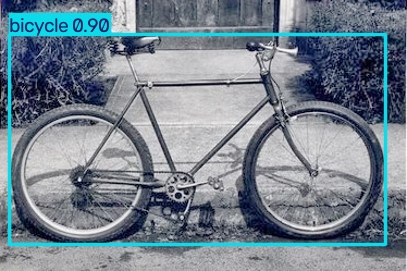

FINE-TUNED YOLO11:


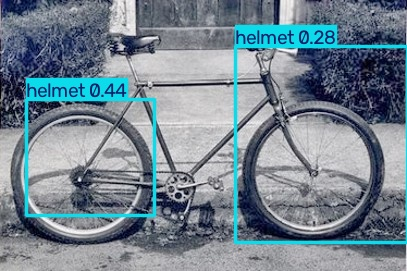

In [ ]:
from IPython.display import Image, display

print("ORIGINAL YOLO11:")
display(Image(
    filename="/content/comparison/original/bikedot.jpg",
    width=600
))

print("FINE-TUNED YOLO11:")
display(Image(
    filename="/content/comparison/fine_tuned/bikedot.jpg",
    width=600
))

In [ ]:
!nvidia-smi

Sat Sep  5 16:37:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q "git+https://github.com/THU-MIG/yoloe.git#subdirectory=third_party/CLIP"
!pip install -q "git+https://github.com/THU-MIG/yoloe.git#subdirectory=third_party/ml-mobileclip"
!pip install -q "git+https://github.com/THU-MIG/yoloe.git#subdirectory=third_party/lvis-api"
!pip install -q "git+https://github.com/THU-MIG/yoloe.git"

!pip install -q supervision jupyter_bbox_widget

!wget -q https://docs-assets.developer.apple.com/ml-research/datasets/mobileclip/mobileclip_blt.pt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.7 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import hf_hub_download

path = hf_hub_download(repo_id="jameslahm/yoloe", filename="yoloe-v8l-seg.pt", local_dir='.')
path = hf_hub_download(repo_id="jameslahm/yoloe", filename="yoloe-v8l-seg-pf.pt", local_dir='.')

yoloe-v8l-seg.pt: reconstructing file:   0%|          |  0.00B /  107MB            

yoloe-v8l-seg.pt: downloading bytes:           |  0.00B            

yoloe-v8l-seg-pf.pt: reconstructing file:   0%|          |  0.00B /  103MB            

yoloe-v8l-seg-pf.pt: downloading bytes:           |  0.00B            

In [ ]:
import supervision as sv
from ultralytics import YOLOE
from PIL import Image

IMAGE_PATH = "dog.jpeg"

NAMES = [
    "dog",
    "eye",
    "tongue",
    "nose",
    "ear"
]

model = YOLOE("yoloe-v8l-seg.pt").cuda()

model.set_classes(
    NAMES,
    model.get_text_pe(NAMES)
)

image = Image.open(IMAGE_PATH)

results = model.predict(
    image,
    conf=0.1,
    verbose=False
)

ModuleNotFoundError: No module named 'supervision'

In [ ]:
!pip install -q supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 13.7 MB/s eta 0:00:00


In [ ]:
import supervision as sv

print("Supervision version:", sv.__version__)
print("Supervision installed successfully!")

Supervision version: 0.30.2
Supervision installed successfully!


In [ ]:
import supervision as sv
from ultralytics import YOLOE
from PIL import Image

print("Everything imported successfully!")

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
!pip install -q ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.6 MB/s eta 0:00:00


In [ ]:
import supervision as sv
import ultralytics

print("Supervision:", sv.__version__)
print("Ultralytics:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Supervision: 0.30.2
Ultralytics: 8.4.142


In [ ]:
from ultralytics import YOLOE
from PIL import Image

print("YOLOE imported successfully!")

YOLOE imported successfully!


In [ ]:
import supervision as sv
from ultralytics import YOLOE
from PIL import Image
import torch

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bikedot.jpg to bikedot.jpg


In [ ]:
print(uploaded.keys())

dict_keys(['bikedot.jpg'])


In [ ]:
model = YOLOE("yoloe-11l-seg.pt")

print("YOLOE model loaded!")

YOLOE model loaded!


In [ ]:
names = [
    "bicycle",
    "helmet",
    "person"
]

model.set_classes(
    names,
    model.get_text_pe(names)
)

print("YOLOE classes:", names)

requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 37 packages in 1.25s
Prepared 2 packages in 2.19s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@a13192f8cb767260d7dfd98c843b0716593169e7)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 4.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

YOLOE classes: ['bicycle', 'helmet', 'person']


In [ ]:
IMAGE_PATH = "bikedot.jpg"

image = Image.open(IMAGE_PATH)

results = model.predict(
    image,
    conf=0.1,
    verbose=False
)

print("Detection complete!")

Detection complete!


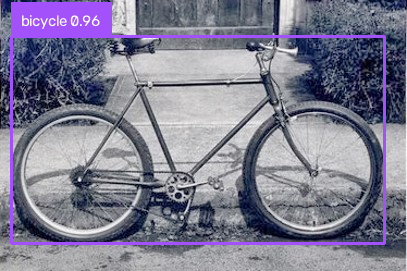

In [ ]:
detections = sv.Detections.from_ultralytics(results[0])

labels = [
    f"{results[0].names[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()

annotated_image = sv.BoxAnnotator().annotate(
    scene=annotated_image,
    detections=detections
)

annotated_image = sv.LabelAnnotator().annotate(
    scene=annotated_image,
    detections=detections,
    labels=labels
)

display(annotated_image)

In [ ]:
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = result.names[class_id]

        print(f"{class_name}: {confidence:.2f}")

bicycle: 0.96


In [ ]:
names = [
    "helmet",
    "hard hat",
    "person"
]

model.set_classes(
    names,
    model.get_text_pe(names)
)

In [ ]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())

Saving yellow-hard-hat-gloves-and.jpg to yellow-hard-hat-gloves-and.jpg
dict_keys(['yellow-hard-hat-gloves-and.jpg'])


In [ ]:
names = [
    "hard hat",
    "helmet",
    "person"
]

model.set_classes(
    names,
    model.get_text_pe(names)
)

print("YOLOE is looking for:", names)

YOLOE is looking for: ['hard hat', 'helmet', 'person']


In [ ]:
from PIL import Image

image = Image.open(IMAGE_PATH)

results = model.predict(
    image,
    conf=0.1,
    verbose=False
)

print("Detection complete!")

Detection complete!


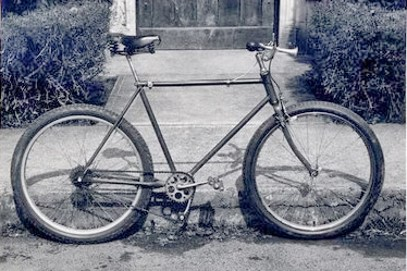

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(results[0])

labels = [
    f"{results[0].names[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()

annotated_image = sv.BoxAnnotator().annotate(
    scene=annotated_image,
    detections=detections
)

annotated_image = sv.LabelAnnotator().annotate(
    scene=annotated_image,
    detections=detections,
    labels=labels
)

display(annotated_image)

In [ ]:
IMAGE_PATH = "yellow-hard-hat-gloves-and.jpg"

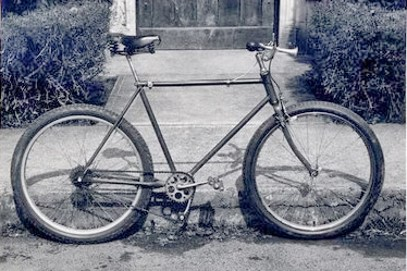

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(results[0])

labels = [
    f"{results[0].names[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()

annotated_image = sv.BoxAnnotator().annotate(
    scene=annotated_image,
    detections=detections
)

annotated_image = sv.LabelAnnotator().annotate(
    scene=annotated_image,
    detections=detections,
    labels=labels
)

display(annotated_image)

In [ ]:
print("YOLOE DETECTIONS")
print("----------------")

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = result.names[class_id]

        print(f"{class_name}: {confidence:.2f}")

YOLOE DETECTIONS
----------------


In [ ]:
names = ["hard hat"]

model.set_classes(
    names,
    model.get_text_pe(names)
)

results = model.predict(
    image,
    conf=0.1,
    verbose=False
)

In [ ]:
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = result.names[class_id]

        print(f"{class_name}: {confidence:.2f}")

In [ ]:
from google.colab import files

uploaded = files.upload()
print("Uploaded file:", list(uploaded.keys()))

Saving yellow-hard-hat-gloves-and.jpg to yellow-hard-hat-gloves-and (1).jpg
Uploaded file: ['yellow-hard-hat-gloves-and (1).jpg']


In [ ]:
HARDHAT_IMAGE_PATH = list(uploaded.keys())[0]

print("Hard-hat image path:", HARDHAT_IMAGE_PATH)

Hard-hat image path: yellow-hard-hat-gloves-and (1).jpg


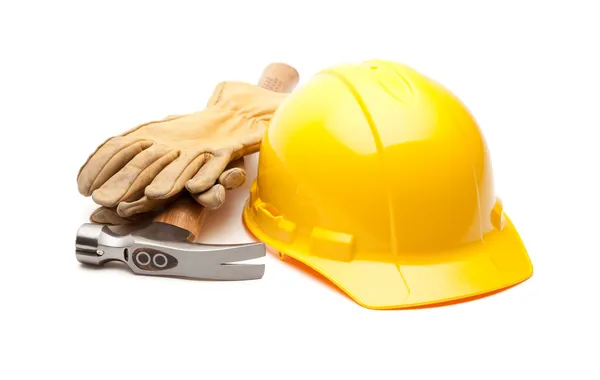

In [ ]:
from PIL import Image
from IPython.display import display

hardhat_image = Image.open(HARDHAT_IMAGE_PATH)

display(hardhat_image)

In [ ]:
hardhat_classes = [
    "hard hat",
    "hammer",
    "gloves"
]

model.set_classes(
    hardhat_classes,
    model.get_text_pe(hardhat_classes)
)

print("YOLOE is looking for:", hardhat_classes)

YOLOE is looking for: ['hard hat', 'hammer', 'gloves']


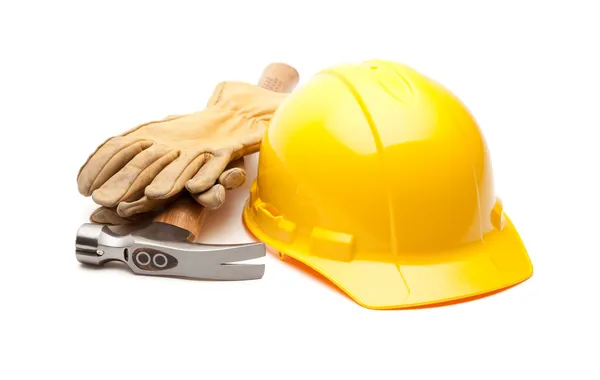

In [ ]:
hardhat_image

In [ ]:
hardhat_results = model.predict(
    hardhat_image,
    conf=0.1,
    verbose=False
)

print("Hard-hat detection complete!")

Hard-hat detection complete!


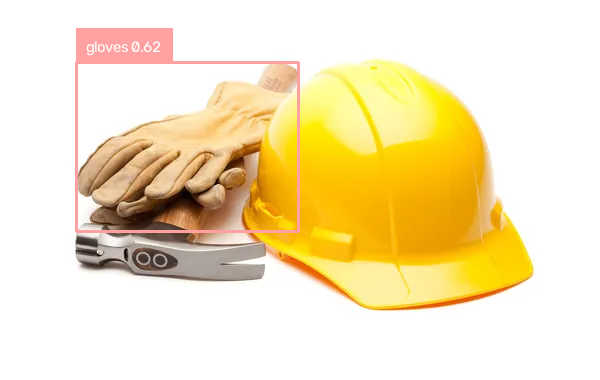

In [ ]:
import supervision as sv

hardhat_detections = sv.Detections.from_ultralytics(
    hardhat_results[0]
)

hardhat_labels = [
    f"{hardhat_results[0].names[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(
        hardhat_detections.class_id,
        hardhat_detections.confidence
    )
]

hardhat_annotated = hardhat_image.copy()

hardhat_annotated = sv.BoxAnnotator().annotate(
    scene=hardhat_annotated,
    detections=hardhat_detections
)

hardhat_annotated = sv.LabelAnnotator().annotate(
    scene=hardhat_annotated,
    detections=hardhat_detections,
    labels=hardhat_labels
)

display(hardhat_annotated)

In [ ]:
print("YOLOE HARD-HAT TEST RESULTS")
print("---------------------------")

for result in hardhat_results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = result.names[class_id]

        print(f"{class_name}: {confidence:.2f}")

YOLOE HARD-HAT TEST RESULTS
---------------------------
gloves: 0.62


In [1]:
!ls /content/datasets/runs/detect/train/

ls: cannot access '/content/datasets/runs/detect/train/': No such file or directory
